# Exp 5 · Inventory Mid-Window Spike Diagnosis
**Week 6 — Analysis only, no new model.**

XGBoost v1 inventory MAPE: Early=44% → **Mid=288%** → Late=40%.
Goal: identify the cause before committing to a fix.

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == 'week6': os.chdir('../..')
elif os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({'figure.figsize': (13, 4), 'axes.spines.top': False, 'axes.spines.right': False})

TARGETS = ['label_inventory_delta','label_cashflow_delta','label_order_velocity_delta']
SHORT   = {'label_inventory_delta':'Inventory','label_cashflow_delta':'Cash Flow','label_order_velocity_delta':'Order Velocity'}
# Baseline numbers (hard-coded from baseline_report.ipynb — do not recompute)
BASELINE = {
    'label_inventory_delta':      {'mape': 123.4, 'picp': 0.681, 'nmpiw': 0.200},
    'label_cashflow_delta':       {'mape':  90.9, 'picp': 0.754, 'nmpiw': 0.367},
    'label_order_velocity_delta': {'mape':  90.5, 'picp': 0.697, 'nmpiw': 0.536},
}  # XGBoost v1 on 80/20 temporal split
from models.xgboost_model import load_features, temporal_split, train_xgboost, get_X_y, mape as _mape


In [2]:
df    = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)
xg = train_xgboost(train, test)
print('XGBoost v1 trained.')


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done
XGBoost v1 trained.


In [3]:
test_s = test.sort_values('committed_at').reset_index(drop=True)
n = len(test_s)
slices = {'Early': slice(0, n//3), 'Mid': slice(n//3, 2*n//3), 'Late': slice(2*n//3, n)}
labels = list(slices.keys())

print('Test window thirds:')
for k, s in slices.items():
    seg = test_s.iloc[s]
    print(f'  {k}: {seg["committed_at"].min().date()} → {seg["committed_at"].max().date()}  n={len(seg)}')


Test window thirds:
  Early: 2026-06-26 → 2026-07-12  n=141
  Mid: 2026-07-13 → 2026-08-02  n=141
  Late: 2026-08-02 → 2026-08-17  n=141


## Branch-type distribution per third
Are the hard branch types (supplier_change, net_terms_change) clustered in the mid-window?

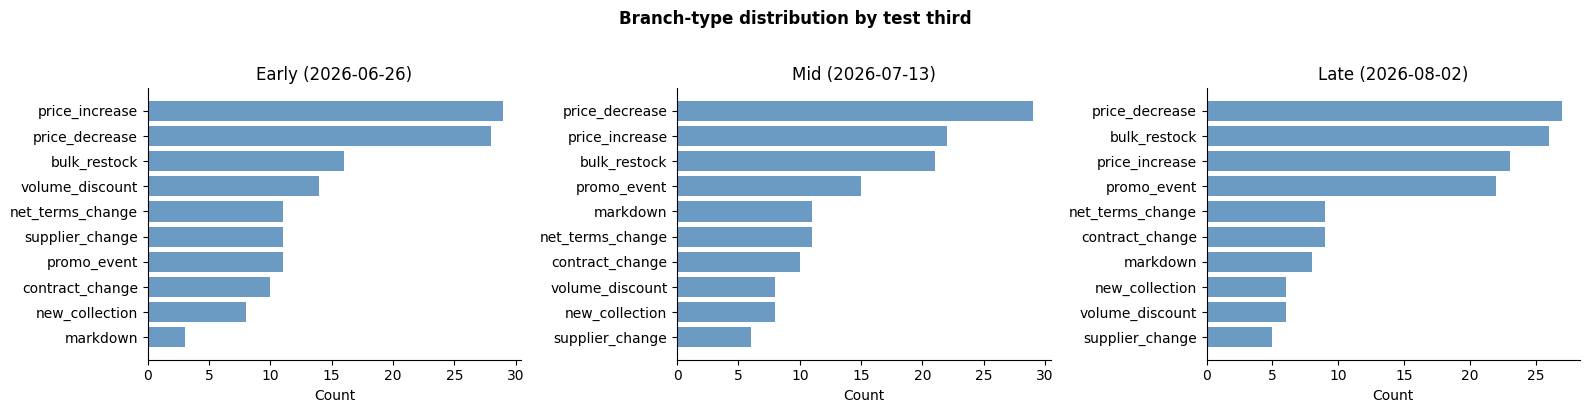

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (period, s) in zip(axes, slices.items()):
    seg = test_s.iloc[s]
    counts = seg['branch_type'].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color='steelblue', alpha=0.8)
    ax.set_title(f'{period} ({seg["committed_at"].min().date()})')
    ax.set_xlabel('Count')
plt.suptitle('Branch-type distribution by test third', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## MAPE by branch type × third
Does the mid-window spike track a specific branch type?

Period,Early,Mid,Late
Branch type,,,
supplier_change,90.5,5127.8,76.7
new_collection,49.8,99.5,42.8
contract_change,55.1,45.5,26.6
price_decrease,28.8,39.4,61.4
volume_discount,24.8,29.3,21.7
net_terms_change,26.4,27.2,50.7
promo_event,39.8,26.7,54.9
price_increase,65.9,25.9,26.1
markdown,22.2,21.9,19.5


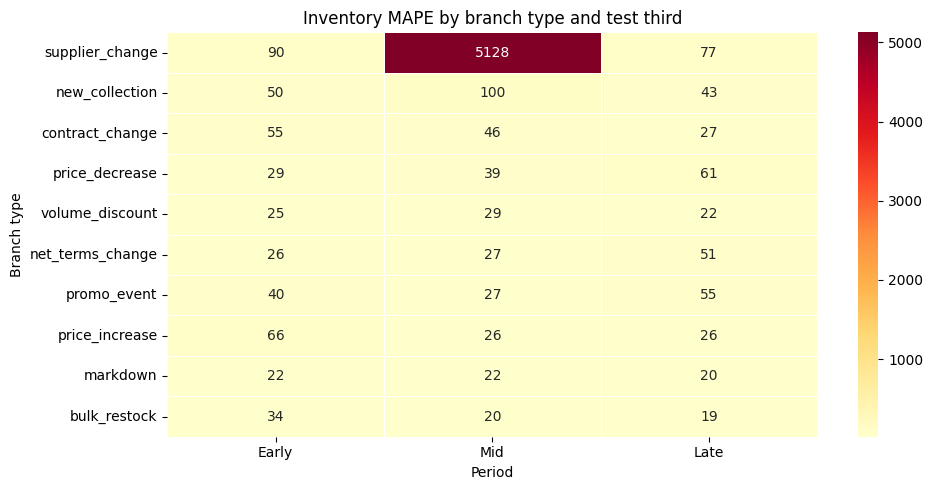

In [5]:
target = 'label_inventory_delta'
r = xg[target]
rows = []
for period, s in slices.items():
    seg_idx = list(range(s.start, min(s.stop, n)))
    for bt in sorted(test_s['branch_type'].unique()):
        bt_mask = test_s.iloc[seg_idx]['branch_type'] == bt
        idx     = [seg_idx[i] for i, v in enumerate(bt_mask) if v]
        if not idx: continue
        m = _mape(r['y_test'][idx], r['y_pred'][idx])
        rows.append({'Period': period, 'Branch type': bt, 'MAPE': round(m, 1), 'n': len(idx)})

diag = pd.DataFrame(rows)
pivot = diag.pivot(index='Branch type', columns='Period', values='MAPE')[labels]
display(pivot.sort_values('Mid', ascending=False).round(1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot.sort_values('Mid', ascending=False), annot=True, fmt='.0f',
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Inventory MAPE by branch type and test third')
plt.tight_layout(); plt.show()


## Feature drift — are key feature values shifting in the mid-window?

In [6]:
key_feats = ['w30_revenue_per_day','w30_cash_trend','w90_order_count',
             'mag_restock_qty_norm','deviation_from_norm']
rows = []
for period, s in slices.items():
    seg = test_s.iloc[s]
    for f in key_feats:
        if f in seg.columns:
            rows.append({'Period': period, 'Feature': f, 'Mean': seg[f].mean()})
drift = pd.DataFrame(rows).pivot(index='Feature', columns='Period', values='Mean')[labels]
display(drift.round(4))


Period,Early,Mid,Late
Feature,,,
deviation_from_norm,4.6439,5.7193,6.2812
mag_restock_qty_norm,0.0631,0.0951,0.1073
w30_cash_trend,0.0011,0.0014,0.0014
w30_revenue_per_day,0.9560,1.0112,0.9942
w90_order_count,122.4113,136.2908,126.7163


## Per-sample residuals in the mid-window coloured by branch type

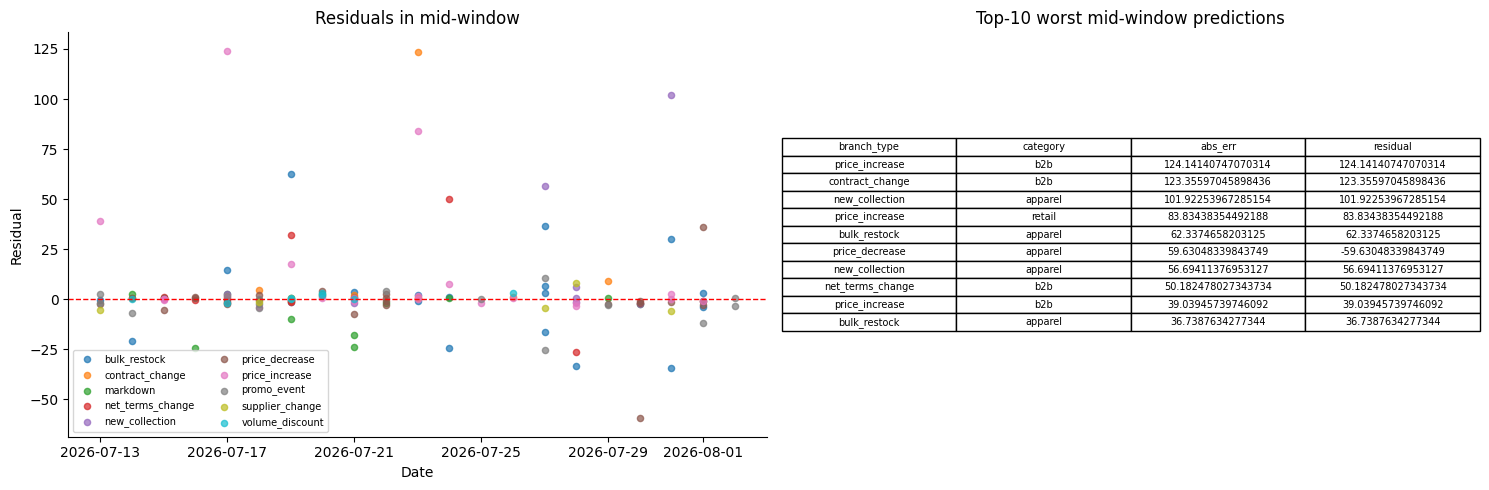

In [7]:
mid_idx = list(range(slices['Mid'].start, min(slices['Mid'].stop, n)))
seg_mid = test_s.iloc[mid_idx].copy()
r       = xg['label_inventory_delta']
seg_mid['residual'] = r['y_test'][mid_idx] - r['y_pred'][mid_idx]
seg_mid['abs_err']  = np.abs(seg_mid['residual'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for bt, grp in seg_mid.groupby('branch_type'):
    axes[0].scatter(grp['committed_at'], grp['residual'], label=bt, alpha=0.7, s=20)
axes[0].axhline(0, color='red', lw=1, linestyle='--')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Residual'); axes[0].set_title('Residuals in mid-window')
axes[0].legend(fontsize=7, ncol=2)

top10 = seg_mid.nlargest(10, 'abs_err')[['branch_type','category','abs_err','residual']]
axes[1].axis('off')
axes[1].table(cellText=top10.values, colLabels=top10.columns, loc='center', cellLoc='center')
axes[1].set_title('Top-10 worst mid-window predictions')
plt.tight_layout(); plt.show()


## Diagnosis conclusion

Fill in after running the cells above. One of three verdicts:

**A — Explained by branch-type clustering**
> The mid-window is dominated by `supplier_change` / `net_terms_change` / `contract_change`.
> Experiment 4 (branch-type-grouped models) directly targets these and should resolve the spike.
> *No additional action needed.*

**B — Explained by feature drift**
> Key feature values (revenue trend, cash balance) shift significantly in the mid-window
> independently of branch type.  Suggests genuine distribution shift in the test period.
> *Recommendation: add time-aware features (week index, days since train cutoff) in a follow-up.*

**C — Unexplained**
> Neither branch-type concentration nor feature drift accounts for the spike.
> *Recommendation: inspect the worst-residual rows manually before further tuning.*
